In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the Fortran binary file
file_path = "dense_FMM_MT.bin"
data = np.fromfile(file_path, dtype=np.float32)  # Adjust dtype as needed
ntot = 2323
kxx_fmm = data[0:ntot*ntot].reshape((ntot, ntot), order="F")
kxy_fmm = data[ntot*ntot:2*ntot*ntot].reshape((ntot, ntot), order="F")
kxz_fmm = data[2*ntot*ntot:3*ntot*ntot].reshape((ntot, ntot), order="F")
kyy_fmm = data[3*ntot*ntot:4*ntot*ntot].reshape((ntot, ntot), order="F")
kyz_fmm = data[4*ntot*ntot:5*ntot*ntot].reshape((ntot, ntot), order="F")
kzz_fmm = data[5*ntot*ntot:6*ntot*ntot].reshape((ntot, ntot), order="F")


# Load the Fortran binary file for "dense_std_MT.bin"
file_path_std = "dense_std_MT.bin"
data_std = np.fromfile(file_path_std, dtype=np.float32)  # Adjust dtype as needed
kxx_std = data_std[0:ntot*ntot].reshape((ntot, ntot), order="F")
kxy_std = data_std[ntot*ntot:2*ntot*ntot].reshape((ntot, ntot), order="F")
kxz_std = data_std[2*ntot*ntot:3*ntot*ntot].reshape((ntot, ntot), order="F")
kyy_std = data_std[3*ntot*ntot:4*ntot*ntot].reshape((ntot, ntot), order="F")
kyz_std = data_std[4*ntot*ntot:5*ntot*ntot].reshape((ntot, ntot), order="F")
kzz_std = data_std[5*ntot*ntot:6*ntot*ntot].reshape((ntot, ntot), order="F")


file_path_nbor = "nbor_list.bin"
data_nbor = np.fromfile(file_path_nbor, dtype=np.int32)  # Adjust dtype as needed
nbor_list = data_nbor[0:ntot*ntot].reshape((ntot, ntot), order="F")

Max difference: 0.0


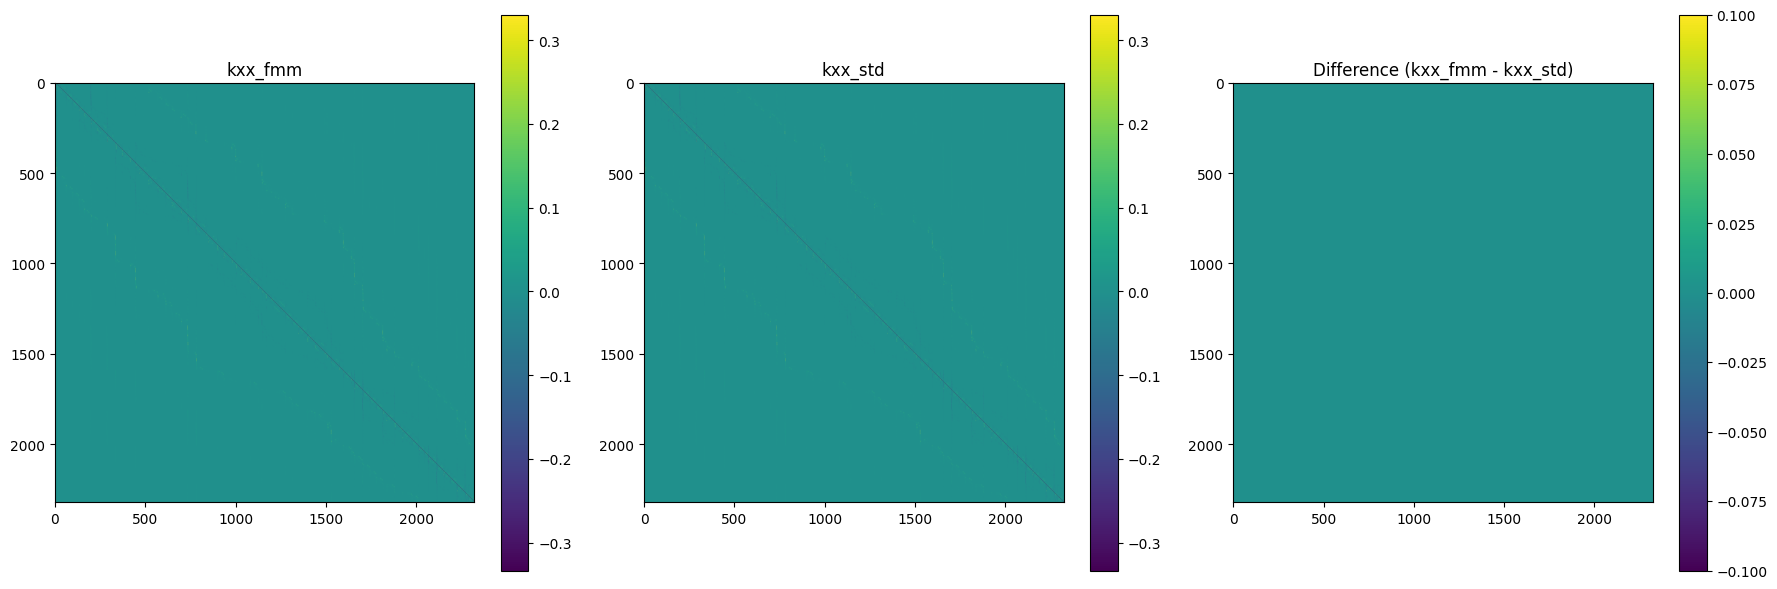

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fmm_val = kzz_fmm
std_val = kzz_std


# Plot kxx_fmm
im1 = axes[0].imshow(fmm_val, cmap='viridis')
axes[0].set_title('kxx_fmm')
fig.colorbar(im1, ax=axes[0])

# Plot kxx_std
im2 = axes[1].imshow(std_val, cmap='viridis')
axes[1].set_title('kxx_std')
fig.colorbar(im2, ax=axes[1])

# Plot the difference
difference = fmm_val - std_val
print("Max difference:", np.max(np.abs(difference)))
im3 = axes[2].imshow(difference, cmap='viridis')
axes[2].set_title('Difference (kxx_fmm - kxx_std)')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [71]:
# Load the Fortran binary file
file_path_dense = "dense_CUDA_H.bin"
data_dense = np.fromfile(file_path_dense, dtype=np.float32)  # Adjust dtype as needed
ntot = 2323
Hx_dense = data_dense[0:ntot]
Hy_dense = data_dense[ntot:2*ntot]
Hz_dense = data_dense[2*ntot:3*ntot]



# Load the Fortran binary file for "dense_std_MT.bin"
file_path_sparse = "sparse_CUDA_H_1.bin"
data_sparse = np.fromfile(file_path_sparse, dtype=np.float32)  # Adjust dtype as needed
Hx_sparse = data_sparse[0:ntot]
Hy_sparse = data_sparse[ntot:2*ntot]
Hz_sparse = data_sparse[2*ntot:3*ntot]


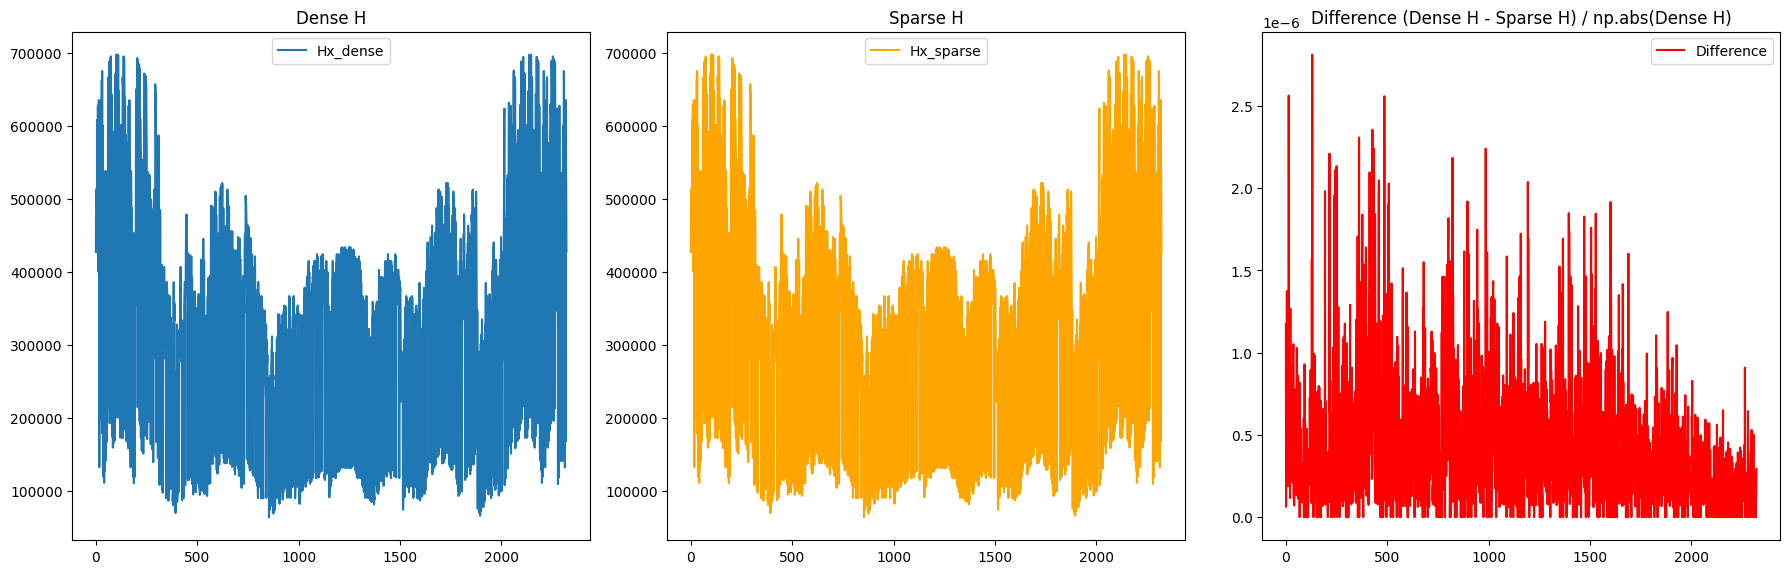

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dense_val  = Hz_dense
sparse_val = Hz_sparse

# Plot dense values
axes[0].plot(dense_val, label='Hx_dense')
axes[0].set_title('Dense H')
axes[0].legend()

# Plot sparse values
axes[1].plot(sparse_val, label='Hx_sparse', color='orange')
axes[1].set_title('Sparse H')
axes[1].legend()

# Plot the difference
difference = np.abs(dense_val - sparse_val) / np.abs(dense_val)
axes[2].plot(difference, label='Difference', color='red')
axes[2].set_title('Difference (Dense H - Sparse H) / np.abs(Dense H)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [82]:
# Load the Fortran binary file
#file_path_sparse_1 = "dense_CUDA_H_1.bin"
file_path_sparse_1 = "sparse_CUDA_H_7.bin"

data_sparse_1 = np.fromfile(file_path_sparse_1, dtype=np.float32)  # Adjust dtype as needed
ntot = 2323
Hx_sparse_1 = data_sparse_1[0:ntot]
Hy_sparse_1 = data_sparse_1[ntot:2*ntot]
Hz_sparse_1 = data_sparse_1[2*ntot:3*ntot]



# Load the Fortran binary file for "dense_std_MT.bin"
#file_path_sparse_2 = "dense_CUDA_H_2.bin"
file_path_sparse_2 = "sparse_CUDA_H_8.bin"
data_sparse_2 = np.fromfile(file_path_sparse_2, dtype=np.float32)  # Adjust dtype as needed
Hx_sparse_2 = data_sparse_2[0:ntot]
Hy_sparse_2 = data_sparse_2[ntot:2*ntot]
Hz_sparse_2 = data_sparse_2[2*ntot:3*ntot]  

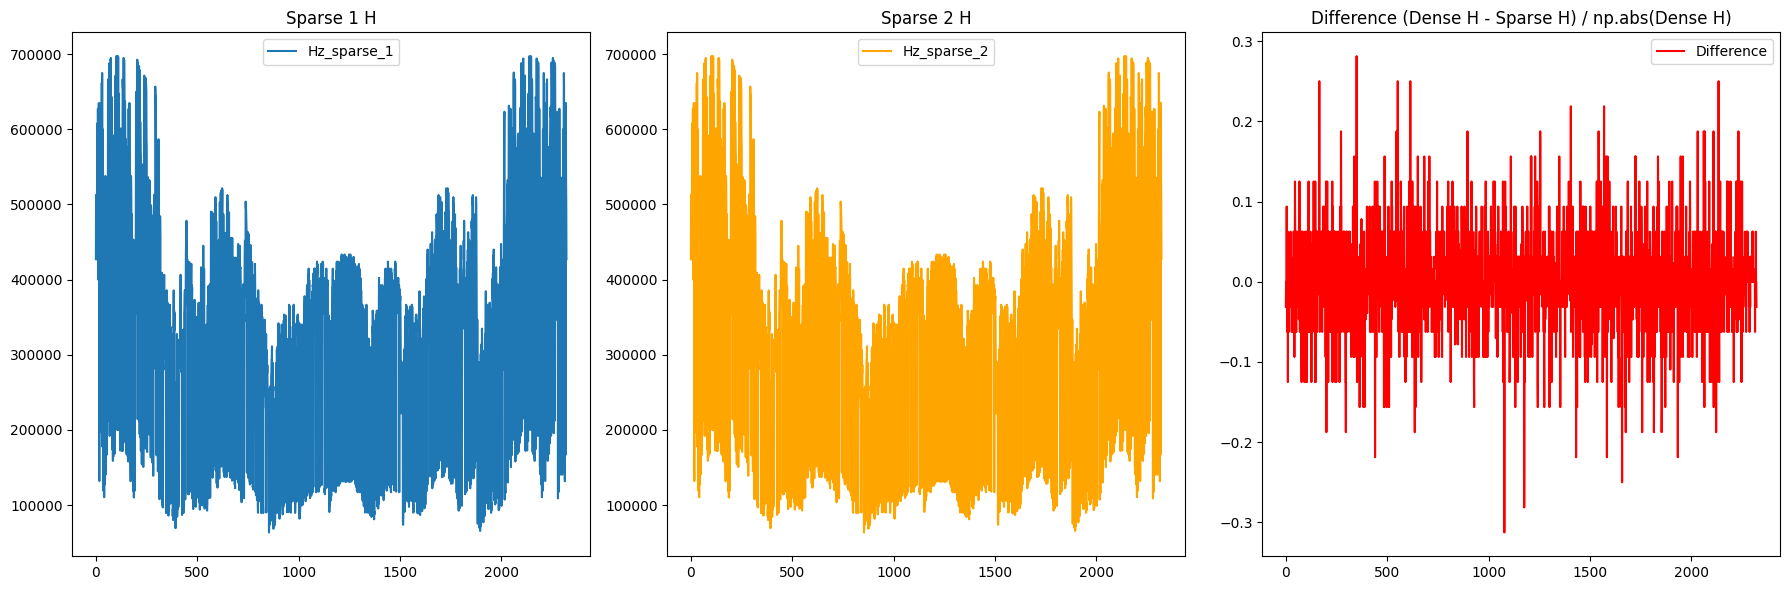

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sparse_1_val = Hz_sparse_1
sparse_2_val = Hz_sparse_2

# Plot dense values
axes[0].plot(sparse_1_val, label='Hz_sparse_1')
axes[0].set_title('Sparse 1 H')
axes[0].legend()

# Plot sparse values
axes[1].plot(sparse_2_val, label='Hz_sparse_2', color='orange')
axes[1].set_title('Sparse 2 H')
axes[1].legend()

# Plot the difference
#difference = np.abs(sparse_1_val - sparse_2_val) #/ np.abs(sparse_1_val)
difference = sparse_1_val - sparse_2_val #/ np.abs(sparse_1_val)

axes[2].plot(difference, label='Difference', color='red')
axes[2].set_title('Difference (Dense H - Sparse H) / np.abs(Dense H)')
axes[2].legend()

plt.tight_layout()
plt.show()